# Modules

In [2]:
import json
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
import pingouin as pg

import seaborn as sns

from itertools import combinations
from scipy.stats import spearmanr

from longitudinal_arm_swing.constants import *
from longitudinal_arm_swing.utils import determine_affected_side_watch_side_mapping, calculate_pvalue, plot_significance, calculate_ci, bca_ci

# Constants

In [3]:
clinical_data_file_name = 'clinical_data.parquet'
digital_measures_file_name = 'digital_measures.parquet'

updrs_score_map = {
    'updrs_2_total': 'Subscore UPDRS Part II',
}

for score_category in ['rigidity', 'bradykinesia', 'hypokinesia']:
    updrs_score_map[f'updrs_3_{score_category}_off_ws'] = f'{score_category.capitalize()} Part III OFF watch side'
    updrs_score_map[f'updrs_3_{score_category}_on_ws'] = f'{score_category.capitalize()} Part III ON watch side'
    updrs_score_map[f'updrs_3_{score_category}_off_non_ws'] = f'{score_category.capitalize()} Part III OFF non-watch side'
    updrs_score_map[f'updrs_3_{score_category}_on_non_ws'] = f'{score_category.capitalize()} Part III ON non-watch side'

aggregates = ['median', '95p', 'median_cov']
quantifications = ['range_of_motion']
measures = [f'{agg}_{quant}' for agg in aggregates for quant in quantifications]

segment_lengths = ['0_20', '20_inf']

cs_weeks = [1, 2]

save_plots = False

# Load

In [4]:
df_clinical = pd.read_parquet(PATH_CLINICAL_DATA / clinical_data_file_name)

df_measures = pd.read_parquet(BASE_PATH / 'measures' / digital_measures_file_name)

with open(PATH_IDS / 'ids_remaining_after_exclusions.json', 'r') as file:
    ids_remaining =  json.load(file)

with open(PATH_IDS / 'med_info_ids.json', 'r') as file:
    med_info_ids = json.load(file)

# Prepare data

In [4]:
no_med_ids = med_info_ids['groups']['start_med']['ppp'] + med_info_ids['groups']['no_med']['ppp'] + med_info_ids['groups']['start_med']['denovo'] + med_info_ids['groups']['no_med']['denovo']
no_med_ids = set([x.replace('_no_med', '').replace('med', '') for x in no_med_ids])
med_ids = [x.replace('_no_med', '').replace('_med', '') for x in med_info_ids['groups']['med']['ppp'] + med_info_ids['groups']['med']['denovo']]
med_ids = set([x for x in med_ids if x not in no_med_ids])

cross_sectional_ids = ids_remaining['ppp']['cs'] + ids_remaining['denovo']['cs'] + ids_remaining['controls']['cs']

In [5]:
# Keep only cross-sectional data
df_clinical = df_clinical.loc[df_clinical['visit']==1]
df_measures = df_measures.loc[df_measures['week'].isin(cs_weeks)]

# Merge clinical data into measures
df = pd.merge(df_measures, df_clinical, on=['id', 'dataset', 'affected_side'], how='left')

# Remove participants which do not adhere to inclusion criteria
df = df.loc[df['id'].isin(cross_sectional_ids)]

df.loc[df['dataset'].isin(['ppp', 'denovo']), 'group'] = 'PD'
df.loc[df['dataset']=='controls', 'group'] = 'controls'

dominant_side_ids = df.loc[
    (
        (df['WatchSide'] == 'left') &
        (df['PrefHand'] == 2)
    ) | (
        (df['WatchSide'] == 'right') &
        (df['PrefHand'] == 1)
    ),
    'id'
].unique().tolist()

for dataset in df['dataset'].unique():
    print(f"Dataset: {dataset} -- N participants: {df.loc[df['dataset']==dataset, 'id'].nunique()}")

Dataset: ppp -- N participants: 388
Dataset: denovo -- N participants: 78
Dataset: controls -- N participants: 45


In [6]:
# Determine most affected side
df_pd_v1 = df_clinical.loc[(df_clinical['dataset'].isin(['ppp', 'denovo'])) & (df_clinical['visit'] == 1)].copy()

affected_side_mapping = {}
for method in ['rigidity', 'bradykinesia', 'hypokinesia']:
    affected_side_mapping[method] = determine_affected_side_watch_side_mapping(df_pd_v1, method)

# Process data
### RQ1 - Construct validity
1. Correlations: Spearman correlation MDS-UPDRS

In [7]:
df_cs = df.loc[(df['include_in_cross_sectional_analysis'] == True) & (df['week'] == 2)].copy()

df_cs.to_parquet(BASE_PATH / 'measures' / 'digital_measures_cross_sectional.parquet', index=False)

In [8]:
df_cs['updrs_3_bradykinesia_upper_off_ws'] = df_cs[['Up3OfFiTaYesDev', 'Up3OfProSYesDev', 'Up3OfHaMoYesDev']].sum(axis=1)
df_cs['updrs_3_bradykinesia_upper_on_ws'] = df_cs[['Up3OnFiTaYesDev', 'Up3OnProSYesDev', 'Up3OnHaMoYesDev']].sum(axis=1)
df_cs['updrs_3_bradykinesia_upper_off_non_ws'] = df_cs[['Up3OfFiTaNonDev', 'Up3OfProSNonDev', 'Up3OfHaMoNonDev']].sum(axis=1)
df_cs['updrs_3_bradykinesia_upper_on_non_ws'] = df_cs[['Up3OnFiTaNonDev', 'Up3OnProSNonDev', 'Up3OnHaMoNonDev']].sum(axis=1)

df_cs['updrs_3_bradykinesia_lower_off_ws'] = df_cs[['Up3OfLAgiYesDev', 'Up3OfToTaYesDev']].sum(axis=1)
df_cs['updrs_3_bradykinesia_lower_on_ws'] = df_cs[['Up3OnLAgiYesDev', 'Up3OnToTaYesDev']].sum(axis=1)
df_cs['updrs_3_bradykinesia_lower_off_non_ws'] = df_cs[['Up3OfLAgiNonDev', 'Up3OfToTaNonDev']].sum(axis=1)
df_cs['updrs_3_bradykinesia_lower_on_non_ws'] = df_cs[['Up3OnLAgiNonDev', 'Up3OnToTaNonDev']].sum(axis=1)

df_cs['updrs_2_bradykinesia_rigidity'] = df_cs[['Updrs2It17', 'Updrs2It18', 'Updrs2It19', 'Updrs2It20']].sum(axis=1)
df_cs['updrs_2_gait_and_balance'] = df_cs['Updrs2It25'].copy()

df_cs['pdq39_brady_rig'] = df_cs[['Pdq39It11', 'Pdq39It12', 'Pdq39It13', 'Pdq39It14', 'Pdq39It15', 'Pdq39It16']].sum(axis=1)
df_cs['pdq39_balance'] = df_cs['Pdq39It09'].copy()
df_cs['pdq39_gait'] = df_cs[['Pdq39It04', 'Pdq39It05', 'Pdq39It06']].sum(axis=1)

C:\Users\z665206\AppData\Local\Temp\ipykernel_12532\1590442794.py:183: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


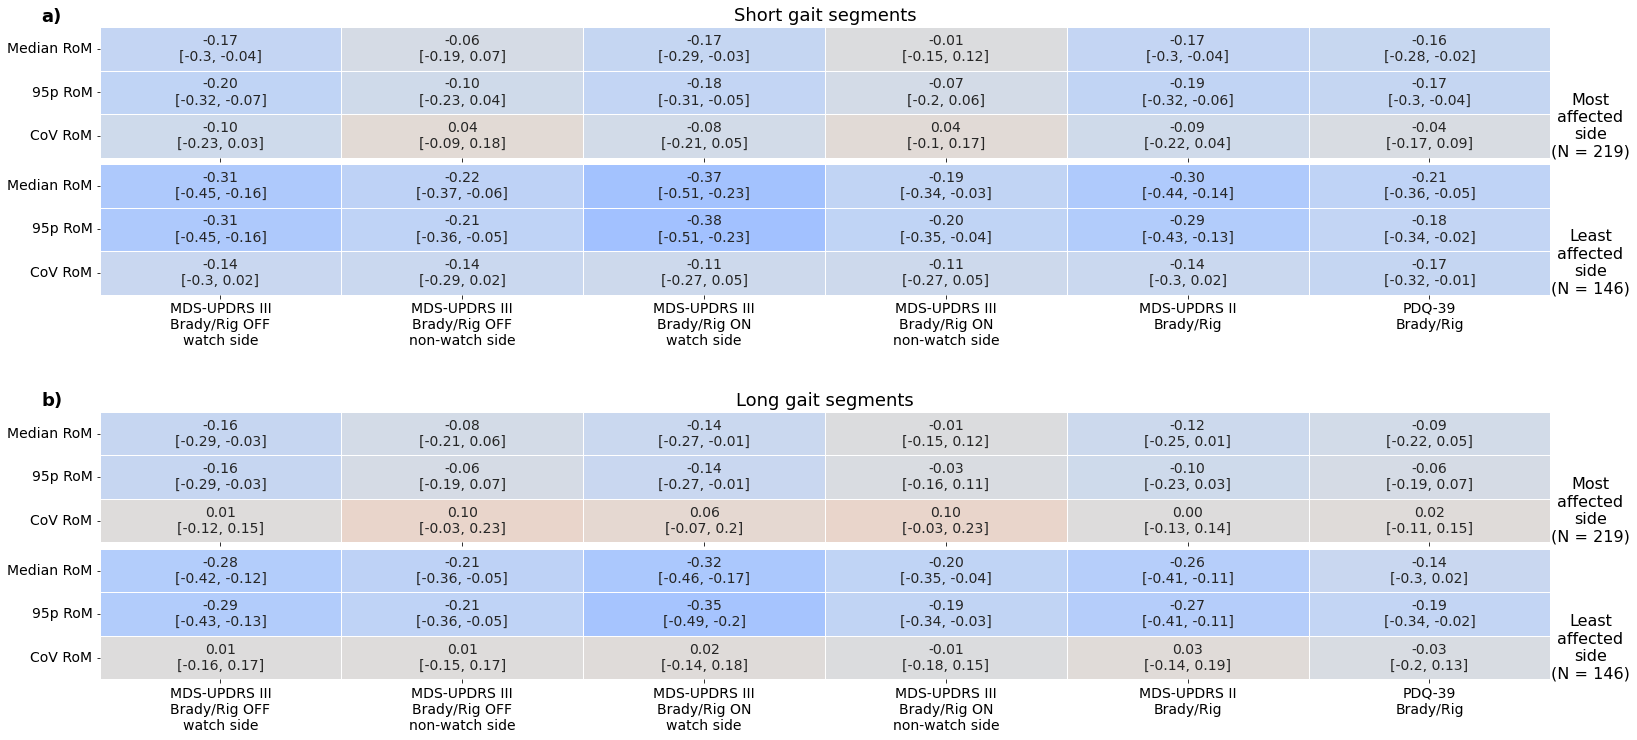

In [9]:
from matplotlib import gridspec

filter_type = 'filtered'
segment_lengths = ['0_20', '20_inf']
med_status = 'med'

plot_vals = 'ci' # ci / pvals

clinical_scores = {
    'updrs_3_hypokinesia_off_ws': 'MDS-UPDRS III\nBrady/Rig OFF\nwatch side',
    'updrs_3_hypokinesia_off_non_ws': 'MDS-UPDRS III\nBrady/Rig OFF\nnon-watch side',
    'updrs_3_hypokinesia_on_ws': 'MDS-UPDRS III\nBrady/Rig ON\nwatch side',
    'updrs_3_hypokinesia_on_non_ws': 'MDS-UPDRS III\nBrady/Rig ON\nnon-watch side',
    'updrs_2_bradykinesia_rigidity': 'MDS-UPDRS II\nBrady/Rig',
    'pdq39_brady_rig': 'PDQ-39\nBrady/Rig',
    # 'Up3OfGait': 'MDS-UPDRS III\nOFF Gait',
    # 'Up3OnGait': 'MDS-UPDRS III\nON Gait',
    # 'pdq39_gait': 'PDQ-39\nGait',
    # 'updrs_2_gait_and_balance': 'MDS-UPDRS II\nGait & Balance',
    # 'Up3OfStaPos': 'MDS-UPDRS III\nOFF Balance',
    # 'Up3OnStaPos': 'MDS-UPDRS III\nON Balance',
    # 'pdq39_balance': 'PDQ-39\nBalance',
}

df_cs_plot = df_cs.loc[df_cs['filter_type'] == filter_type].copy()

df_cs_plot.loc[df_cs_plot['WatchSide']=='left', 'Up3OfRigWSue'] = df_cs_plot.loc[df_cs_plot['WatchSide'] == 'left', 'Up3OfRigLue'].copy()
df_cs_plot.loc[df_cs_plot['WatchSide']=='left', 'Up3OfRigNWSue'] = df_cs_plot.loc[df_cs_plot['WatchSide'] == 'left', 'Up3OfRigRue'].copy()
df_cs_plot.loc[df_cs_plot['WatchSide']=='right', 'Up3OfRigWSue'] = df_cs_plot.loc[df_cs_plot['WatchSide'] == 'right', 'Up3OfRigRue'].copy()
df_cs_plot.loc[df_cs_plot['WatchSide']=='right', 'Up3OfRigNWSue'] = df_cs_plot.loc[df_cs_plot['WatchSide'] == 'right', 'Up3OfRigLue'].copy()
df_cs_plot.loc[df_cs_plot['WatchSide']=='left', 'Up3OfRigWSle'] = df_cs_plot.loc[df_cs_plot['WatchSide'] == 'left', 'Up3OfRigLle'].copy()
df_cs_plot.loc[df_cs_plot['WatchSide']=='left', 'Up3OfRigNWSle'] = df_cs_plot.loc[df_cs_plot['WatchSide'] == 'left', 'Up3OfRigRle'].copy()
df_cs_plot.loc[df_cs_plot['WatchSide']=='right', 'Up3OfRigWSle'] = df_cs_plot.loc[df_cs_plot['WatchSide'] == 'right', 'Up3OfRigRle'].copy()
df_cs_plot.loc[df_cs_plot['WatchSide']=='right', 'Up3OfRigNWSle'] = df_cs_plot.loc[df_cs_plot['WatchSide'] == 'right', 'Up3OfRigLle'].copy()

nrows_total = 4
ncols = 1

if med_status == 'med':
    width = 26
else:
    width = 12

fig = plt.figure(figsize=(width, 12))

gs = gridspec.GridSpec(
    nrows_total + 1,  # +1 row slot for the gap
    ncols,
    height_ratios=[1, 1, 0.8, 1, 1],  # 0.15 is the space between (a) and (b)
    hspace=0.05,
    wspace=0.02
)

axes = []
for i in range(nrows_total):
    row_idx = i if i < 2 else i + 1  # skip the 3rd grid row (the gap)
    row_axes = [fig.add_subplot(gs[row_idx, j]) for j in range(ncols)]
    axes.append(row_axes)

for i, segment_length in enumerate(segment_lengths):
    for j, affected_side in enumerate(['mas', 'las']):
        ax = axes[2 * i + j][0]
        
        heatmap_data = {}
        annot_data = {}

        if med_status == 'med':
            med_status_ids = med_ids
        else:
            med_status_ids = no_med_ids

        df_filtered = df_cs_plot.loc[
            (df_cs_plot['id'].isin(med_status_ids)) &
            (df_cs_plot['affected_side'] == affected_side) &
            (df_cs_plot['segment_category'] == segment_length)
        ]

        if df_filtered.empty:
            continue

        for measure in measures:
            row_label = f'{measure.replace("_", " ").capitalize()}'
            x = df_filtered[measure]
            if x.isnull().all():
                continue

            heatmap_data[row_label] = {}
            annot_data[row_label] = {}

            for clinical_score, clinical_label in clinical_scores.items():
                y = df_filtered[clinical_score]
                if y.isnull().all():
                    continue

                valid_idx = (~x.isnull()) & (~y.isnull())
                corr, p_val = spearmanr(x[valid_idx], y[valid_idx])
                samples = df_filtered.loc[valid_idx, ['id', 'dataset']].drop_duplicates().shape[0]

                if plot_vals == 'pvals':
                    if p_val < 0.001:
                        lower_label = '(p < 0.001)'
                    elif p_val < 0.01:
                        lower_label = '(p < 0.01)'
                    elif p_val < 0.05:
                        lower_label = '(p < 0.05)'
                    else:
                        lower_label = f'(p = {np.round(p_val, 2)})'
                elif plot_vals == 'ci':
                    lower, upper = calculate_ci(x[valid_idx], corr)
                    lower_label = f'[{np.round(lower, 2)}, {np.round(upper, 2)}]'

                heatmap_data[row_label][clinical_label] = corr
                annot_data[row_label][clinical_label] = f"{corr:.2f}\n{lower_label}"

        corr_df = pd.DataFrame.from_dict(heatmap_data, orient='index')
        annot_df = pd.DataFrame.from_dict(annot_data, orient='index')

        row_order = list(corr_df.index)
        if med_status == 'med':
            corr_df.loc['Medicated', :] = np.nan
            annot_df.loc['Medicated', :] = ""

        if med_status == 'no_med':
            corr_df.loc['Unmedicated', :] = np.nan
            annot_df.loc['Unmedicated', :] = ""
            
        corr_df = corr_df.loc[row_order]
        annot_df = annot_df.loc[row_order]

        corr_df.index = [x.replace('Medicated ', '').replace('Unmedicated ', '').replace('MAS', 'Most affected side').replace('LAS', 'Least affected side').replace('range of motion', 'RoM').replace('Median cov', 'CoV') for x in corr_df.index]
        annot_df.index = [x.replace('Medicated ', '').replace('Unmedicated ', '').replace('MAS', 'Most affected side').replace('LAS', 'Least affected side').replace('range of motion', 'RoM').replace('Median cov', 'CoV') for x in annot_df.index]

        # Plot
        sns.heatmap(
            corr_df,
            annot=annot_df,
            fmt="",
            cmap="coolwarm",
            center=0,
            linewidths=0.5,
            cbar=False,
            vmin=-1, vmax=1,
            annot_kws={"size": PLOT_TEXTSIZE},
            ax=ax
        )

        ax.yaxis.set_label_position("right")

        ax.tick_params(axis='both', which='major', labelsize=PLOT_TICKSIZE)
        plt.setp(ax.get_xticklabels(), rotation=0, fontsize=PLOT_TICKSIZE)
        plt.setp(ax.get_yticklabels(), rotation=0, fontsize=PLOT_TICKSIZE)

        if j == 0:
            ax.set_xticklabels([])
            ylabel = f"Most\naffected\nside\n(N = {df_filtered.shape[0]})"
        else:
            ylabel = f"Least\naffected\nside\n(N = {df_filtered.shape[0]})"
        
        axes[2 * i + j][0].set_ylabel(ylabel, rotation=0, labelpad=40, size=PLOT_LABELSIZE)

        yticks = ax.get_yticklabels()
        for tick in yticks:
            if tick.get_text() in ['Medicated', 'Unmedicated']:
                tick.set_fontweight('bold')
                tick.set_fontsize(PLOT_TICKSIZE)

        if i == 0 and j == 0:
            subplot_label = 'a)'
        elif i == 1 and j == 0:
            subplot_label = 'b)'
        else:
            continue

        ax.text(
            -0.04, 1.15, subplot_label, fontweight='bold',
            ha='left', va='top', fontsize=PLOT_TITLESIZE,
            transform=ax.transAxes
        )

axes[0][0].set_title("Short gait segments", fontsize=PLOT_TITLESIZE)
axes[2][0].set_title("Long gait segments", fontsize=PLOT_TITLESIZE)

plt.tight_layout()
# plt.subplots_adjust(top=0.92)
plt.show()

fig.savefig(PATH_FIGURES / f'{med_status}.png', dpi=300)

In [10]:
# # Correlation between clincial scores
# clinical_scores = {
#     'updrs_3_hypokinesia_off_ws': 'Part III\nsubscore OFF',
#     'updrs_3_hypokinesia_on_ws': 'Part III\nsubscore ON',
#     'updrs_2_total': 'Part II\ntotal score',
# }

# clinical_cols = list(clinical_scores.keys()) + ['YearsSinceDiagFloat']

# heatmap_data = {}
# annot_data = {}

# fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(16, 20), sharey=False)

# for i, (med_status, med_status_ids) in enumerate(zip(['med', 'no_med'], [med_ids, no_med_ids])):
#     for j, affected_side in enumerate(['mas', 'las']):
#         df_med_status = df_cs.loc[
#             (df_cs['id'].isin(med_status_ids)) &
#             (df_cs['affected_side'] == affected_side)
#         ]

#         if df_med_status.empty:
#             continue

#         if med_status == 'no_med':
#             clinical_cols_plot = [x for x in clinical_cols if x != 'updrs_3_hypokinesia_on_ws']
#         else:
#             clinical_cols_plot = clinical_cols

#         # print(f"{med_status} - {affected_side}\n{df_med_status[['YearsSinceDiagFloat', 'pdq39_mobility']].dropna().corr()}\n")

#         sns.heatmap(data=df_med_status[clinical_cols_plot].corr(), ax=axes[i, j], cmap="coolwarm", center=0, vmin=-1, vmax=1, annot=True, fmt=".2f", annot_kws={"size": PLOT_TEXTSIZE}, linewidths=0.5, cbar=False)

#         axes[i, j].set_title(f"{GROUP_RENAMING[med_status].capitalize()} {affected_side.upper()}", fontsize=PLOT_TITLESIZE)

# plt.tight_layout()
# plt.show()

mas 0_20 all 294
Median range of motion
95p range of motion
Median cov range of motion
mas 20_inf all 294
Median range of motion
95p range of motion
Median cov range of motion
las 0_20 all 165
Median range of motion
95p range of motion
Median cov range of motion
las 20_inf all 165
Median range of motion
95p range of motion
Median cov range of motion


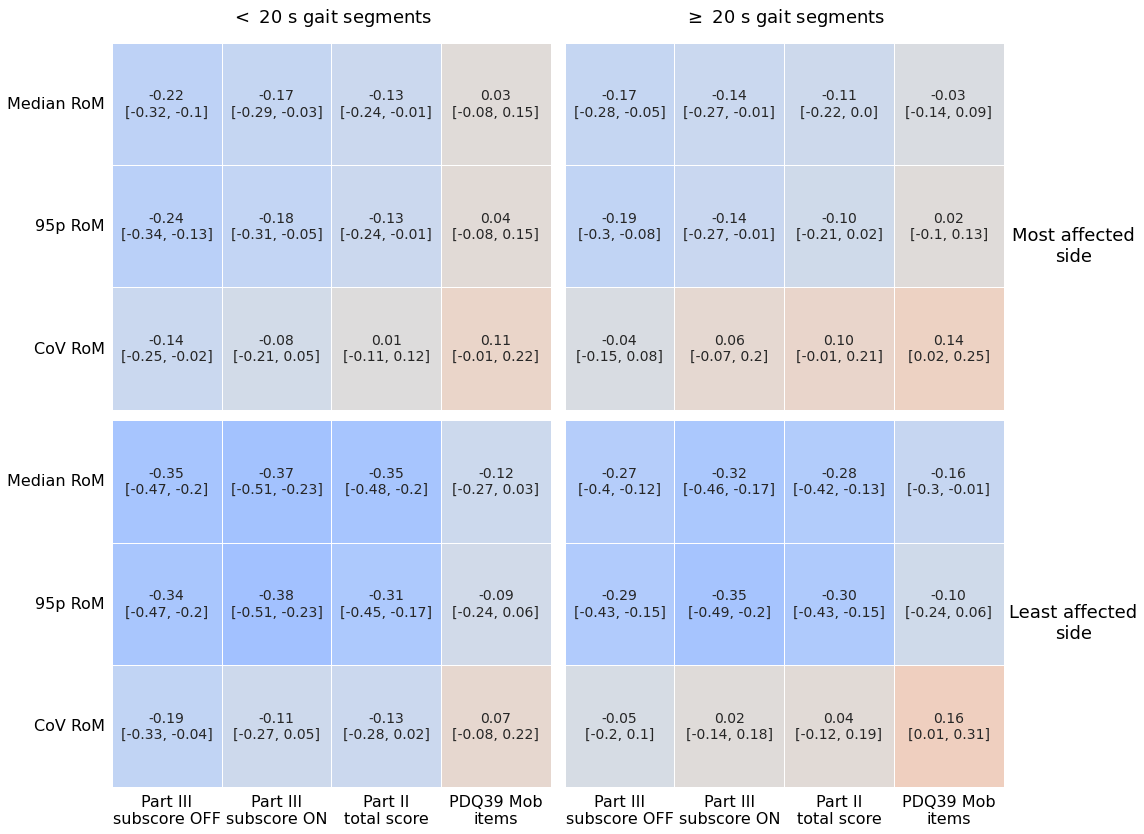

In [11]:
filter_type = 'filtered'
segment_lengths = ['0_20', '20_inf']
med_split = False  # True for separate med/no_med, False to combine
plot_vals = 'ci'  # ci / pvals

clinical_scores = {
    'updrs_3_hypokinesia_off_ws': 'Part III\nsubscore OFF',
    'updrs_3_hypokinesia_on_ws': 'Part III\nsubscore ON',
    'updrs_2_total': 'Part II\ntotal score',
    'pdq39_mobility': 'PDQ39 Mob\nitems',
}

df_cs_plot = df_cs.loc[df_cs['filter_type'] == filter_type]

sides = ['mas', 'las']
side_labels = ['Most affected side', 'Least affected side']
measures_order = ['Median RoM', '95p RoM', 'CoV RoM']

fig, axes = plt.subplots(nrows=2, ncols=len(segment_lengths), figsize=(16, 12), sharex=True, sharey=True)

for i, affected_side in enumerate(['mas', 'las']):
    for j, segment_length in enumerate(segment_lengths):
        if len(segment_lengths) == 1:
            ax = axes[i]
        else:
            ax = axes[i, j]
        heatmap_data = {}
        annot_data = {}

        if med_split:
            status_ids = zip(['med', 'no_med'], [med_ids, no_med_ids])
        else:
            status_ids = [('all', list(med_ids) + list(no_med_ids))]

        for med_status, med_status_ids in status_ids:
            df_filtered = df_cs_plot.loc[
                (df_cs_plot['id'].isin(med_status_ids)) &
                (df_cs_plot['affected_side'] == affected_side) &
                (df_cs_plot['segment_category'] == segment_length)
            ]
            if df_filtered.empty:
                continue

            print(affected_side, segment_length, med_status, df_filtered.shape[0])

            for measure in measures:
                x = df_filtered[measure]
                if x.isnull().all():
                    continue

                row_label = measure.replace("_", " ").capitalize()
                heatmap_data[row_label] = {}
                annot_data[row_label] = {}

                print(row_label)

                for clinical_score, clinical_label in clinical_scores.items():
                    y = df_filtered[clinical_score]
                    if y.isnull().all():
                        continue

                    valid_idx = (~x.isnull()) & (~y.isnull())
                    corr, p_val = spearmanr(x[valid_idx], y[valid_idx])

                    if plot_vals == 'pvals':
                        if p_val < 0.001:
                            lower_label = '(p < 0.001)'
                        elif p_val < 0.01:
                            lower_label = '(p < 0.01)'
                        elif p_val < 0.05:
                            lower_label = '(p < 0.05)'
                        else:
                            lower_label = f'(p = {np.round(p_val, 2)})'
                    elif plot_vals == 'ci':
                        lower, upper = calculate_ci(x[valid_idx], corr)
                        lower_label = f'[{np.round(lower, 2)}, {np.round(upper, 2)}]'

                    heatmap_data[row_label][clinical_label] = corr
                    annot_data[row_label][clinical_label] = f"{corr:.2f}\n{lower_label}"

        corr_df = pd.DataFrame.from_dict(heatmap_data, orient='index')
        annot_df = pd.DataFrame.from_dict(annot_data, orient='index')

        corr_df.index = [x.replace('MAS', 'Most affected side')
                           .replace('LAS', 'Least affected side')
                           .replace('range of motion', 'RoM')
                           .replace('Median cov', 'CoV') for x in corr_df.index]
        annot_df.index = [x.replace('MAS', 'Most affected side')
                           .replace('LAS', 'Least affected side')
                           .replace('range of motion', 'RoM')
                           .replace('Median cov', 'CoV') for x in annot_df.index]

        sns.heatmap(
            corr_df,
            annot=annot_df,
            fmt="",
            cmap="coolwarm",
            center=0,
            linewidths=0.5,
            cbar=False,
            vmin=-1, vmax=1,
            annot_kws={"size": PLOT_TEXTSIZE},
            ax=ax
        )

        ax.tick_params(left=False, bottom=False, labelsize=PLOT_LABELSIZE)
        plt.setp(ax.get_yticklabels(), fontsize=PLOT_LABELSIZE, rotation=0)
        plt.setp(ax.get_xticklabels(), rotation=0, fontsize=PLOT_LABELSIZE)

        if i == 0:
            ax.set_title(f"{SEGMENT_DURATION_RENAMING[segment_length]} gait segments", fontsize=PLOT_TITLESIZE, pad=20)

if len(segment_lengths) > 1:
    axes[0, 1].set_ylabel("Most affected\nside", fontsize=PLOT_TITLESIZE, labelpad=70, rotation=0)
    axes[1, 1].set_ylabel("Least affected\nside", fontsize=PLOT_TITLESIZE, labelpad=70, rotation=0)
    axes[0, 1].yaxis.set_label_position("right")
    axes[1, 1].yaxis.set_label_position("right")
else:
    axes[0].set_ylabel("Most affected\nside", fontsize=PLOT_TITLESIZE, labelpad=70, rotation=0)
    axes[1].set_ylabel("Least affected\nside", fontsize=PLOT_TITLESIZE, labelpad=70, rotation=0)
    axes[0].yaxis.set_label_position("right")
    axes[1].yaxis.set_label_position("right")

plt.tight_layout()
plt.subplots_adjust(top=0.92)
plt.show()

if save_plots:
    fig.savefig(PATH_FIGURES / 'r_cs_updrs_corr.png', dpi=600, bbox_inches='tight')
    fig.savefig(PATH_FIGURES / 'vectors' / 'r_cs_updrs_corr.pdf', dpi=600, bbox_inches='tight')


Processing measure: median


C:\Users\z665206\AppData\Local\Temp\ipykernel_12532\3870233574.py:26: UserWarning: The palette list has more values (3) than needed (2), which may not be intended.
  sns.boxplot(x='segment_category', hue='group_long', y=measure_full,


0_20: PD most affected side (N = 219) vs PD least affected side (N = 146) stat: -5.69 [-6.71, -4.46]; p-value:  p = 0.000
20_inf: PD most affected side (N = 219) vs PD least affected side (N = 146) stat: -9.4 [-12.2, -6.79]; p-value:  p = 0.000
Processing measure: 95p


C:\Users\z665206\AppData\Local\Temp\ipykernel_12532\3870233574.py:26: UserWarning: The palette list has more values (3) than needed (2), which may not be intended.
  sns.boxplot(x='segment_category', hue='group_long', y=measure_full,


0_20: PD most affected side (N = 219) vs PD least affected side (N = 146) stat: -12.4 [-15.99, -8.22]; p-value:  p = 0.000
20_inf: PD most affected side (N = 219) vs PD least affected side (N = 146) stat: -17.89 [-23.46, -11.53]; p-value:  p = 0.000
Processing measure: median_cov


C:\Users\z665206\AppData\Local\Temp\ipykernel_12532\3870233574.py:26: UserWarning: The palette list has more values (3) than needed (2), which may not be intended.
  sns.boxplot(x='segment_category', hue='group_long', y=measure_full,


0_20: PD most affected side (N = 219) vs PD least affected side (N = 146) stat: -0.03 [-0.05, -0.02]; p-value:  p = 0.000
20_inf: PD most affected side (N = 219) vs PD least affected side (N = 146) stat: -0.02 [-0.03, -0.01]; p-value:  p = 0.001


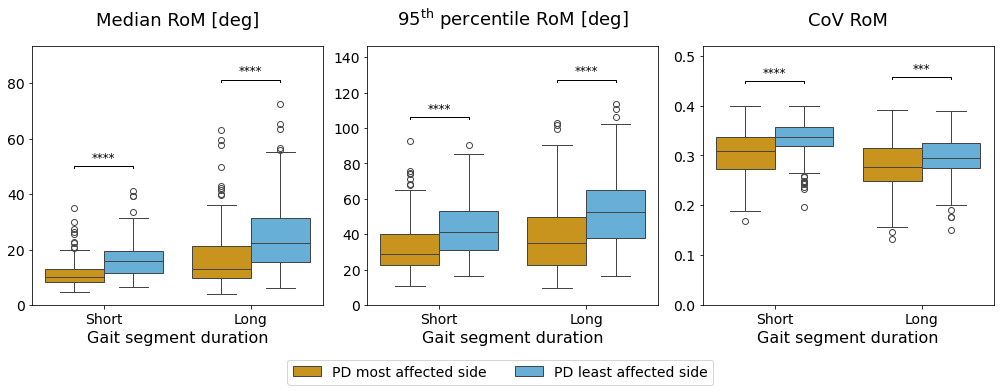

In [13]:
round_pval = False
med_state = 'med'
filter_type = 'filtered'

if med_state in ['no_med', 'med']:
    df_cs_med_state = df_cs.loc[df_cs['med_state'] == med_state]
else:
    df_cs_med_state = df_cs.copy()

df_cs_med_state = df_cs_med_state.loc[(df_cs_med_state['filter_type'] == filter_type) & (df_cs_med_state['segment_category'].isin(segment_lengths))]

df_cs_med_state['affected_side'] = df_cs_med_state['affected_side'].fillna('')

df_cs_med_state.loc[(df_cs_med_state['group'] == 'PD') & (df_cs_med_state['affected_side'] == 'mas'), 'group_long'] = 'PD most affected side'
df_cs_med_state.loc[(df_cs_med_state['group'] == 'PD') & (df_cs_med_state['affected_side'] == 'las'), 'group_long'] = 'PD least affected side'
df_cs_med_state.loc[df_cs_med_state['group'] == 'controls', 'group_long'] = 'Controls'

groups = df_cs_med_state['group_long'].dropna().unique()

fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(14,5), sharex=True)

for i, agg in enumerate(aggregates):
    print(f"Processing measure: {agg}")
    measure_full = f'{agg}_range_of_motion'

    sns.boxplot(x='segment_category', hue='group_long', y=measure_full, 
                data=df_cs_med_state, palette=[COLOR_GROUP_1, COLOR_GROUP_2, COLOR_GROUP_NEUTRAL], ax=ax[i])

    n_groups = len(groups)
    x_positions = {x_label: pos for x_label, pos in zip(segment_lengths, ax[i].get_xticks())}
    box_width = 0.8 / n_groups

    gap_y = np.max(df_cs_med_state[measure_full]) * 0.12

    box_positions = {}
    for length in segment_lengths:
        base_x = x_positions[length]
        for j, group in enumerate(groups):
            x = base_x - 0.4 + box_width * (j + 0.5)
            box_positions[(length, group)] = x

        sub_df = df_cs_med_state[df_cs_med_state['segment_category'] == length]
        present_groups = sub_df['group_long'].dropna().unique()
        max_y = sub_df[measure_full].max()

        for idx, (g1, g2) in enumerate(combinations(present_groups, 2)):
            values1 = sub_df[sub_df['group_long'] == g1][measure_full].dropna()
            values2 = sub_df[sub_df['group_long'] == g2][measure_full].dropna()

            p_value = calculate_pvalue(values1, values2, test='ranksums')[1]

            if round_pval:
                if p_value < 0.001:
                    p_value_str = 'p < 0.001'
                elif p_value < 0.01:
                    p_value_str = 'p < 0.01'
                elif p_value < 0.05:
                    p_value_str = 'p < 0.05'
                else:
                    p_value_str = f'p = {np.round(p_value, 2)}'
            else:
                p_value_str = f'p = {p_value:.3f}'

            pe_diff = np.median(values1) - np.median(values2)
            ci_lower, ci_upper = bca_ci(values1, values2, n_boot=2000, ci=95)

            print(f"{length}: {g1} (N = {len(values1)}) vs {g2} (N = {len(values2)}) stat: {np.round(pe_diff, 2)} [{np.round(ci_lower, 2)}, {np.round(ci_upper, 2)}]; p-value: ", p_value_str)

            x_min = box_positions[(length, g1)]
            x_max = box_positions[(length, g2)]

            if idx == 1:
                y_sig = max_y + 2 * gap_y
            else:
                y_sig = max_y + gap_y

            plot_significance(
                ax=ax[i],
                x_min=x_min,
                x_max=x_max,
                pvalue=p_value,
                y_min_significance=y_sig,
                text_size=PLOT_TEXTSIZE - 2,
            )

        
    ax[i].tick_params(axis='both', labelsize=PLOT_TICKSIZE)
    ax[i].set_ylim(0, 1.1 * ax[i].get_ylim()[1])
    ax[i].set_yticks(ax[i].get_yticks()[:-1])

    xticks = ax[i].get_xticks()
    xtick_labels = ax[i].get_xticklabels()

    # new_labels = [
    #     SEGMENT_DURATION_RENAMING.get(label.get_text(), label.get_text())
    #     for label in xtick_labels
    # ]
    new_labels = ['Short', 'Long']

    ax[i].set_xticks(xticks)
    ax[i].set_xticklabels(new_labels, size=PLOT_TICKSIZE)

    ax[i].tick_params(axis='both', labelsize=PLOT_TICKSIZE)

    if agg == 'median_cov':
        ylabel = f'{AGGREGATION_RENAMING[agg]} RoM'
    else:
        ylabel = f'{AGGREGATION_RENAMING[agg]} RoM [deg]'

    ax[i].set_ylabel('')
    ax[i].set_title(ylabel, size=PLOT_TITLESIZE, pad=20)
    ax[i].set_xlabel('Gait segment duration', size=PLOT_LABELSIZE)

    legend = ax[i].get_legend()
    if legend is not None:
        legend.remove()

handles, labels = ax[0].get_legend_handles_labels()
fig.legend(
    handles, labels,
    loc='lower center',
    ncols=3,
    fontsize=PLOT_LEGEND_FONTSIZE,
    frameon=True,
    bbox_to_anchor=(0.5, -0.1) 
)

fig.tight_layout()

plt.show()

if save_plots:
    fig.savefig(PATH_FIGURES / 'r_cs_group_diff_rom.png', dpi=600, bbox_inches='tight')
    fig.savefig(PATH_FIGURES / 'vectors' / 'r_cs_group_diff_rom.pdf', dpi=600, bbox_inches='tight')

#### With covariate adjustments

Comparing mas and las: PD_MAS - PD_LAS = 0
0_20: median - Δ=-5.07, 95% CI=(-6.17, -3.98), p=0.0
Comparing mas and controls: PD_MAS = 0
0_20: median - Δ=-5.32, 95% CI=(-7.53, -3.12), p=0.0
Comparing las and controls: PD_LAS = 0
0_20: median - Δ=-0.25, 95% CI=(-2.42, 1.92), p=0.8199
Comparing mas and las: PD_MAS - PD_LAS = 0
20_inf: median - Δ=-8.00, 95% CI=(-10.4, -5.6), p=0.0
Comparing mas and controls: PD_MAS = 0
20_inf: median - Δ=-6.27, 95% CI=(-11.08, -1.45), p=0.0109
Comparing las and controls: PD_LAS = 0
20_inf: median - Δ=1.73, 95% CI=(-3.01, 6.48), p=0.4737
Comparing mas and las: PD_MAS - PD_LAS = 0
0_20: 95p - Δ=-10.65, 95% CI=(-13.48, -7.82), p=0.0
Comparing mas and controls: PD_MAS = 0
0_20: 95p - Δ=-12.97, 95% CI=(-18.65, -7.28), p=0.0
Comparing las and controls: PD_LAS = 0
0_20: 95p - Δ=-2.32, 95% CI=(-7.92, 3.28), p=0.4163
Comparing mas and las: PD_MAS - PD_LAS = 0
20_inf: 95p - Δ=-13.75, 95% CI=(-17.86, -9.65), p=0.0
Comparing mas and controls: PD_MAS = 0
20_inf: 95p - Δ

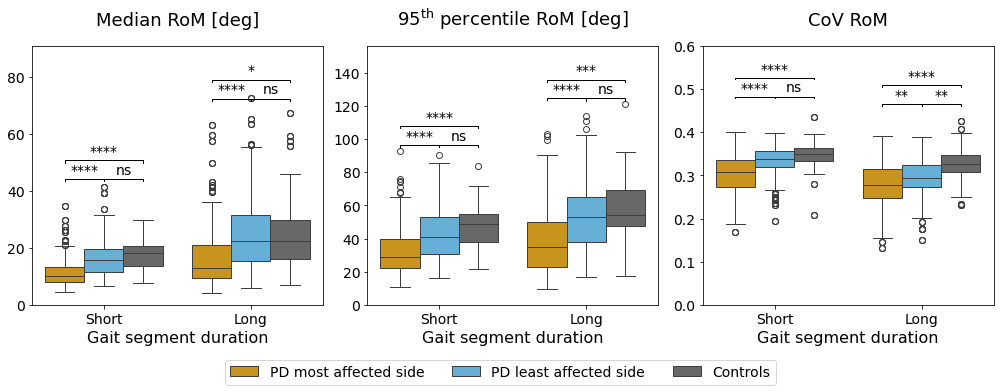

In [29]:
import statsmodels.formula.api as smf
import seaborn as sns
import matplotlib.pyplot as plt

filter_type = 'filtered'
segment_lengths = ['0_20', '20_inf']
verbose = False
med_state = 'med'

df_cs_ols = df_cs.loc[
    (df_cs['filter_type'] == filter_type)
    & (df_cs['segment_category'].isin(segment_lengths))
].copy()

if med_state in ['no_med', 'med']:
    df_cs_ols = df_cs_ols.loc[
        (df_cs_ols['group'] == 'controls') | 
        (
            (df_cs_ols['group'] == 'PD') & 
            (df_cs_ols['med_state'] == med_state)
        )
    ]
    med_state_suffix = f'_{med_state}'
else:
    med_state_suffix = ''

group_renaming = {
    'mas': 'PD most affected side',
    'las': 'PD least affected side',
    'controls': 'Controls'
}

# Binary encodings
df_cs_ols['gender'] = df_cs_ols['Gender'].map({1: 1, 2: 0})
df_cs_ols['dominant_side'] = df_cs_ols['id'].isin(dominant_side_ids).astype(int)
df_cs_ols['group'] = df_cs_ols['affected_side'].map({'mas': 'mas', 'las': 'las'}).fillna('controls')
df_cs_ols['is_pd'] = df_cs_ols['group'].map({'mas': 1, 'las': 1, 'controls': 0})
df_cs_ols['group_long'] = df_cs_ols['group'].map(group_renaming)

def compute_corrected(df, measure_col):
    df_regr = df.copy()
    df_regr = df_regr.rename(columns={measure_col: measure_col.replace("95p", "p95")})
    measure_col = measure_col.replace("95p", "p95")

    # Create group variable
    df_regr['group_regr'] = df_regr.apply(
        lambda r: 'PD_MAS' if r['is_pd']==1 and r['affected_side']=='mas'
        else ('PD_LAS' if r['is_pd']==1 and r['affected_side']=='las' else 'Control'),
        axis=1
    )

    df_regr['updrs_3_on_total'] = df_regr['updrs_3_on_total'].fillna(0)
    df_regr['updrs_pd_interaction'] = df_regr['is_pd'] * df_regr['updrs_3_on_total']
    
    # One-hot encode groups (drop_first -> Control reference)
    group_dummies = pd.get_dummies(df_regr['group_regr'], drop_first=True).astype(int)
    df_regr = pd.concat([df_regr, group_dummies], axis=1)

    # Regression formula
    formula_terms = ['Age', 'gender', 'dominant_side', 'updrs_pd_interaction'] + list(group_dummies.columns)
    formula = f"{measure_col} ~ {' + '.join(formula_terms)}"
    model = smf.ols(formula, data=df_regr).fit()

    # Reference values for covariates (mean for numeric, 0 for group dummies)
    ref_values_base = {
        'Age': df_regr['Age'].mean(),
        'gender': df_regr['gender'].mean(),
        'dominant_side': df_regr['dominant_side'].mean(),
        'updrs_pd_interaction': df_regr.loc[df_regr['is_pd']==1,'updrs_pd_interaction'].mean()
    }

    # Compute predicted value per group
    df_regr[f'{measure_col}_corrected'] = np.nan
    df_regr['resid'] = model.resid

    for grp in ['Control', 'PD_MAS', 'PD_LAS']:
        ref_values = ref_values_base.copy()

        if grp == 'Control':
            ref_values['updrs_pd_interaction'] = 0
            

        # Set group dummy values for this group
        for col in group_dummies.columns:
            ref_values[col] = 1 if col == grp else 0

        # Predicted reference value for this group
        pred_ref = model.params['Intercept'] + sum(model.params[cov] * val for cov, val in ref_values.items())

        # Mask for subjects in this group
        mask = df_regr['group_regr'] == grp
        # Assign corrected value = residual + predicted reference
        df_regr.loc[mask, f'{measure_col}_corrected'] = df_regr.loc[mask, 'resid'] + pred_ref

    return df_regr, model

# Compute corrected values for all measures and segments
corrected_dfs = []
ols_models = {}
for seg_len in segment_lengths:
    df_seg = df_cs_ols[df_cs_ols['segment_category'] == seg_len].copy()
    ols_models[seg_len] = {}

    for agg in aggregates:
        measure_col = f"{agg}_range_of_motion"
        df_regr, ols_models[seg_len][agg] = compute_corrected(df_seg, measure_col)

        corrected_dfs.append(df_regr)

df_corrected = pd.concat(corrected_dfs, ignore_index=True)

# Filter for plotting
df_plot = df_corrected.copy()
# df_plot['group_long'] = df_plot['group_long'].replace({
#     'PD most affected side': 'PD most\naffected side',
#     'PD least affected side': 'PD least\naffected side'
# })

# Plot
fig, axes = plt.subplots(1, len(aggregates), figsize=(14,5), sharex=True)

for i, agg in enumerate(aggregates):
    measure = f"{agg}_range_of_motion".replace("95p", "p95")
    measure_corrected = f"{measure}_corrected".replace("95p", "p95")
    
    sns.boxplot(
        x='segment_category', 
        hue='group_long', 
        y=measure, 
        data=df_plot, 
        palette=[COLOR_GROUP_1, COLOR_GROUP_2, COLOR_GROUP_NEUTRAL], 
        ax=axes[i]
    )
    
    box_positions = {}
    n_segments = len(segment_lengths)
    hue_order = df_plot['group'].dropna().unique()
    n_groups = len(hue_order)
    
    # Compute pairwise statistics
    for seg_idx, seg_len in enumerate(segment_lengths):
        for group_idx, group in enumerate(hue_order):
            x = seg_idx - 0.4 + 0.8 * (group_idx + 0.5) / n_groups
            box_positions[(seg_len, group)] = x

    max_y_delta = 0.1 * df_plot[measure_corrected].max()
    
    # Compute pairwise statistics and plot significance
    for seg_len in segment_lengths:
        sub_df = df_plot[df_plot['segment_category'] == seg_len]
        present_groups = sub_df['group'].dropna().unique()

        max_y = sub_df[measure_corrected].max()
        y_base = max_y + max_y_delta
        
        for idx, (g1, g2) in enumerate(combinations(present_groups, 2)):
            values1 = sub_df[sub_df['group'] == g1][measure_corrected].dropna()
            values2 = sub_df[sub_df['group'] == g2][measure_corrected].dropna()


            if g1 == 'mas' and g2 == 'controls':
                hypothesis = 'PD_MAS = 0'
            elif g1 == 'las' and g2 == 'controls':
                hypothesis = 'PD_LAS = 0'
            else:
                hypothesis = 'PD_MAS - PD_LAS = 0'

            print(f"Comparing {g1} and {g2}: {hypothesis}")

            t_res = ols_models[seg_len][agg].t_test(hypothesis)
            coef = t_res.effect[0]
            pval = t_res.pvalue.item()
            ci_low, ci_high = t_res.conf_int()[0]
            print(f"{seg_len}: {agg} - Δ={coef:.2f}, 95% CI=({np.round(ci_low, 2)}, {np.round(ci_high, 2)}), p={np.round(pval, 4)}")
                        
            x_min = box_positions[(seg_len, g1)]
            x_max = box_positions[(seg_len, g2)]

            if idx == 1:
                y_sig = y_base + max_y_delta
            else:
                y_sig = y_base
            
            plot_significance(
                ax=axes[i], 
                x_min=x_min, 
                x_max=x_max, 
                pvalue=pval,
                y_min_significance=y_sig, 
                text_size=PLOT_TEXTSIZE
            )

    if 'cov' in agg:
        ylabel = f'{AGGREGATION_RENAMING[agg]} RoM'
    else:
        ylabel = f'{AGGREGATION_RENAMING[agg]} RoM [deg]'

    axes[i].set_title(ylabel, size=PLOT_TITLESIZE, pad=20)
    axes[i].set_ylabel('')
    axes[i].set_xlabel('Gait segment duration', size=PLOT_LABELSIZE)
    axes[i].set_xticks(range(len(segment_lengths)), ['Short', 'Long']) #[SEGMENT_DURATION_RENAMING[x] for x in segment_lengths])
    axes[i].tick_params(axis='both', labelsize=PLOT_TICKSIZE)

    axes[i].set_ylim(0, 1.1 * axes[i].get_ylim()[1])

    legend = axes[i].get_legend()
    if legend is not None:
        legend.remove()

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles, labels,
    loc='lower center',
    ncols=3,
    fontsize=PLOT_LEGEND_FONTSIZE,
    frameon=True,
    bbox_to_anchor=(0.5, -0.1) 
)

fig.tight_layout()
plt.show()

if save_plots:
    fig.savefig(PATH_FIGURES / f'r_cs{med_state_suffix}_group_diff_rom_corrected.png', dpi=600, bbox_inches='tight')


### RQ2 - Reliability
1. Test-retest

In [18]:
icc_type = 'ICC2'
filter_type = 'filtered'
segment_length = '0_20'

df_icc = df.loc[
    (df['group'] == 'PD') &
    (df['include_in_icc_analysis']) &
    (df['week'].isin(cs_weeks)) & 
    (df['filter_type'] == filter_type) &
    (df['segment_category'] == segment_length)
].copy()

results = []

for side in ['mas', 'las']:  
    for agg in aggregates:
        agg_label = AGGREGATION_RENAMING[agg]
        df_side = df_icc[df_icc['affected_side'] == side]
        icc = pg.intraclass_corr(data=df_side, targets='id', raters='week', ratings=f'{agg}_range_of_motion', nan_policy='omit')

        results.append((
            f'{agg_label} RoM - {AFFECTED_SIDE_RENAMING[side]}',
            icc.loc[icc['Type'] == icc_type, 'ICC'].values[0],
            icc.loc[icc['Type'] == icc_type, 'pval'].values[0],
            icc.loc[icc['Type'] == icc_type, 'CI95%'].values[0]
        ))

df_icc = pd.DataFrame(results, columns=['Digital measure', 'ICC', 'p-value', 'CI95%'])

df_icc

,Digital measure,ICC,p-value,CI95%
0,Median RoM - Most affected side,0.951780,1.673675e-152,"[0.94, 0.96]"
1,95$^{\mathrm{th}}$ percentile RoM - Most affec...,0.921763,1.060821e-122,"[0.9, 0.94]"
2,CoV RoM - Most affected side,0.917861,9.534579e-120,"[0.9, 0.93]"
3,Median RoM - Least affected side,0.924621,2.547619e-71,"[0.9, 0.94]"
4,95$^{\mathrm{th}}$ percentile RoM - Least affe...,0.974606,1.060156e-108,"[0.97, 0.98]"
5,CoV RoM - Least affected side,0.922019,1.266414e-69,"[0.9, 0.94]"


#### Correlation between digital measures

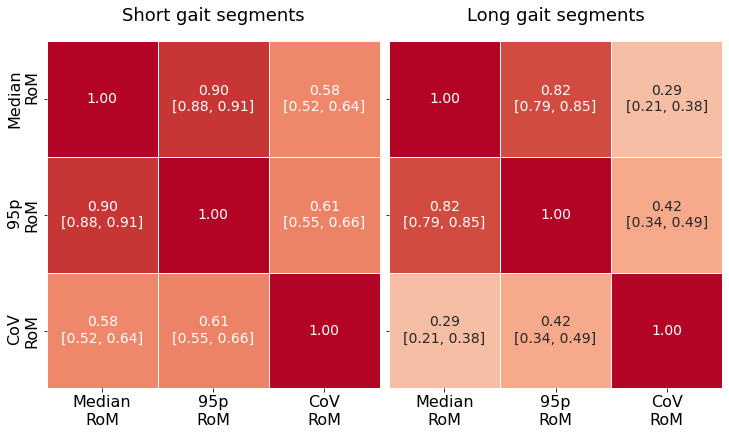

In [19]:
import seaborn as sns
from scipy.stats import spearmanr

plot_vals = 'ci'  # 'ci' or 'pvals'

fig, ax = plt.subplots(ncols=2, figsize=(12, 6), sharey=True)

df_corr = df.loc[
    (df['filter_type'] == 'filtered') &
    (df['group'] == 'PD') &
    (df['week'] == 1) 
    # (df['id'].isin(list(med_ids) + list(no_med_ids))),
]

for j, segment_length in enumerate(segment_lengths):
    df_segment = df_corr.loc[df_corr['segment_category'] == segment_length]

    if df_segment.empty:
        print(f"No data available for segment length: {segment_length}")
        continue

    median_rom = df_segment['median_range_of_motion'].values
    p_rom = df_segment['95p_range_of_motion'].values
    cv_rom = df_segment['median_cov_range_of_motion'].values

    corr_input_df = pd.DataFrame({
        'Median\nRoM': median_rom,
        '95p\nRoM': p_rom,
        'CoV\nRoM': cv_rom,
    })

    corr_df = corr_input_df.corr(method='spearman')
    annot_df = corr_df.copy().astype(str)

    for row in corr_df.columns:
        for col in corr_df.columns:
            if row == col:
                annot_df.loc[row, col] = "1.00"
                continue

            x = corr_input_df[row]
            y = corr_input_df[col]
            valid_idx = (~pd.isnull(x)) & (~pd.isnull(y))
            corr, p_val = spearmanr(x[valid_idx], y[valid_idx])

            if plot_vals == 'pvals':
                if p_val < 0.001:
                    lower_label = "(p < 0.001)"
                elif p_val < 0.01:
                    lower_label = "(p < 0.01)"
                elif p_val < 0.05:
                    lower_label = "(p < 0.05)"
                else:
                    lower_label = f"(p = {np.round(p_val, 2)})"
            elif plot_vals == 'ci':
                lower, upper = calculate_ci(x[valid_idx], corr)  # your helper
                lower_label = f"[{np.round(lower, 2)}, {np.round(upper, 2)}]"

            annot_df.loc[row, col] = f"{corr:.2f}\n{lower_label}"

    sns.heatmap(
        corr_df,
        annot=annot_df,
        fmt="",
        cmap="coolwarm",
        center=0,
        linewidths=0.5,
        cbar=False,
        vmin=-1, vmax=1,
        annot_kws={"size": PLOT_TEXTSIZE},
        ax=ax[j]
    )

    ax[j].tick_params(axis='both', which='major', labelsize=PLOT_LABELSIZE)

    # if j == 0:
    #     subplot_label = 'a)'
    # else:
    #     subplot_label = 'b)'

    # ax[j].text(
    #     0.02, 1.05, subplot_label, fontweight='bold',
    #     ha='left', va='top', fontsize=PLOT_TITLESIZE,
    #     transform=ax[j].transAxes
    # )

ax[0].set_title('Short gait segments', fontsize=PLOT_TITLESIZE, pad=20)
ax[1].set_title('Long gait segments', fontsize=PLOT_TITLESIZE, pad=20)

plt.tight_layout()
plt.subplots_adjust(top=0.92, right=0.84)
plt.show()

if save_plots:
    fig.savefig(PATH_FIGURES / 'sr_cs_corr_measures.png', dpi=600, bbox_inches='tight')
    fig.savefig(PATH_FIGURES / 'vectors' /'sr_cs_corr_measures.pdf', dpi=600, bbox_inches='tight')


### Age vs digital measures

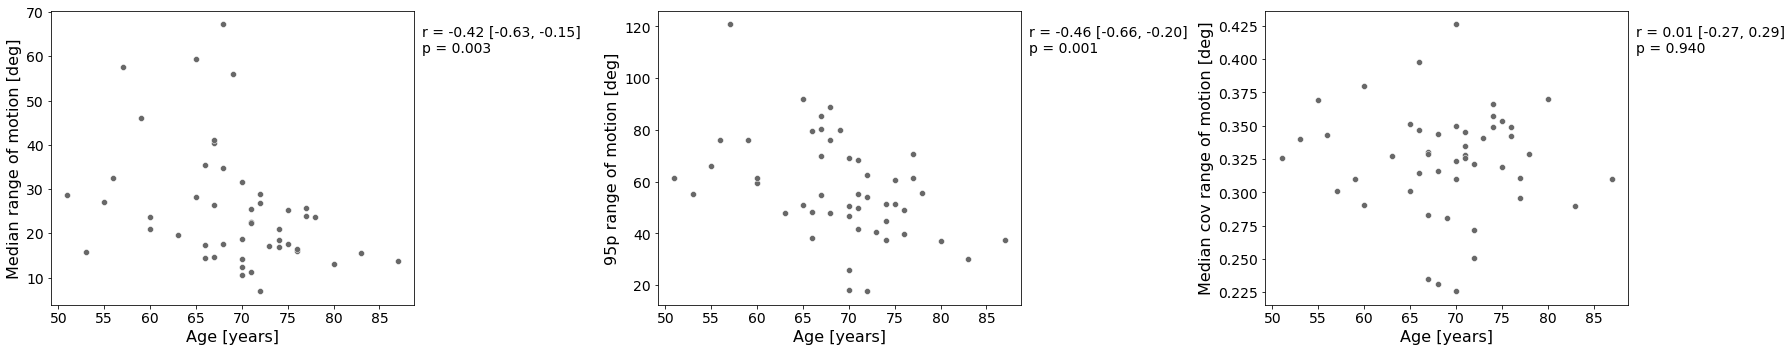

In [20]:
df_measures_controls = df_measures.loc[
    (df_measures['dataset'] == 'controls') &
    (df_measures['week'] == 2) & 
    (df_measures['filter_type'] == 'filtered') &
    (df_measures['segment_category'] == '20_inf')
].copy()

df_measures_controls = df_measures_controls.merge(
    df_clinical[['id', 'Age']],
    on='id', how='left'
)

fig, ax = plt.subplots(ncols=3, figsize=(25, 5), sharex=True)

for j, measure in enumerate(measures):
    sns.scatterplot(
        x='Age', y=measure,
        data=df_measures_controls,
        ax=ax[j],
        color=COLOR_GROUP_NEUTRAL
    )

    x = df_measures_controls['Age']
    y = df_measures_controls[measure]
    valid_idx = (~x.isnull()) & (~y.isnull())
    corr, p_val = spearmanr(x[valid_idx], y[valid_idx])

    lower, upper = calculate_ci(x[valid_idx], corr) 

    # print(f"{measure.replace('_', ' ').capitalize()} - Spearman's r = {corr:.2f} [{lower:.2f}, {upper:.2f}], p = {p_val:.3f}")
    ax[j].text(1.02, 0.95, f"r = {corr:.2f} [{lower:.2f}, {upper:.2f}]\np = {p_val:.3f}", transform=ax[j].transAxes, fontsize=PLOT_TEXTSIZE, verticalalignment='top', horizontalalignment='left')
    ax[j].set_xlabel('Age [years]', fontsize=PLOT_LABELSIZE)
    ax[j].set_ylabel(f'{measure.replace("_", " ").capitalize()} [deg]', fontsize=PLOT_LABELSIZE)
    ax[j].tick_params(axis='both', labelsize=PLOT_TICKSIZE)
    ax[j].grid(False)
    
plt.tight_layout()
plt.show()

### Robustness analyses

In [5]:
path_propark_data = BASE_PATH / 'arm_swing_aggregations' / 'propark'
files = [f for f in os.listdir(path_propark_data) if f.endswith('_arm_swing_aggregates.json')]

invalid_ids = ['55285', '48943', '52474']  # Insufficient data

if invalid_ids:
    files = [f for f in files if not any(x in f for x in invalid_ids)]

propark_aggs = {}
for file in files:
    subject = file.split('_')[0]
    
    with open(path_propark_data / file, 'r') as f:
        propark_aggs[subject] = json.load(f)

df_clinical_propark = pd.read_csv(PATH_CLINICAL_DATA / 'clinical_data_propark.csv', sep=';')
df_clinical_propark = df_clinical_propark.rename(columns=PROPARK_CLINICAL_COL_RENAME)
df_clinical_propark = df_clinical_propark.loc[df_clinical_propark['visit'] == 'T00']
df_clinical_propark['watch_side'] = df_clinical_propark['watch_side'].map({0: 'left', 1: 'right'})
df_clinical_propark['group'] = df_clinical_propark['group'].map({1: 'pd', 2: 'controls'})
df_clinical_propark['gender'] = df_clinical_propark['gender'].map({'Vrouw': 0, 'Man': 1})

# Add UPDRS columns
left_cols = ['updrs_3_3c', 'updrs_3_3e', 'updrs_3_4b', 'updrs_3_5b', 'updrs_3_6b', 'updrs_3_7b', 'updrs_3_8b']
right_cols = ['updrs_3_3b', 'updrs_3_3d', 'updrs_3_4a', 'updrs_3_5a', 'updrs_3_6a', 'updrs_3_7a', 'updrs_3_8a']

df_clinical_propark.loc[
    df_clinical_propark['watch_side'] == 'left', 
    'updrs_3_hypokinesia_off_ws'
] = df_clinical_propark.loc[
    df_clinical_propark['watch_side'] == 'left', 
    left_cols
].sum(axis=1)
df_clinical_propark.loc[
    df_clinical_propark['watch_side'] == 'right', 
    'updrs_3_hypokinesia_off_ws'
] = df_clinical_propark.loc[
    df_clinical_propark['watch_side'] == 'right', 
    right_cols
].sum(axis=1)
df_clinical_propark.loc[
    df_clinical_propark['watch_side'] == 'left', 
    'updrs_3_hypokinesia_off_non_ws'
] = df_clinical_propark.loc[
    df_clinical_propark['watch_side'] == 'left', 
    right_cols
].sum(axis=1)
df_clinical_propark.loc[
    df_clinical_propark['watch_side'] == 'right', 'updrs_3_hypokinesia_off_non_ws'
] = df_clinical_propark.loc[df_clinical_propark['watch_side'] == 'right', left_cols].sum(axis=1)
df_clinical_propark['affected_side'] = df_clinical_propark.apply(
    lambda x: 'mas' if x['updrs_3_hypokinesia_off_ws'] > x['updrs_3_hypokinesia_off_non_ws'] else
    ('las' if x['updrs_3_hypokinesia_off_ws'] < x['updrs_3_hypokinesia_off_non_ws'] else np.nan), 
    axis=1
)
df_clinical_propark.loc[df_clinical_propark['group'] == 'controls', 'affected_side'] = 'controls'

In [6]:
aggs_rows = []
for subject, subject_aggs in propark_aggs.items():
    for filter_type in ['filtered', 'unfiltered']:
        for segment_category in subject_aggs[filter_type].keys():
            row = {
                'id': int(subject),
                'filter_type': filter_type,
                'segment_category': segment_category,
            }
            row.update(subject_aggs[filter_type][segment_category])
            aggs_rows.append(row)

df_aggs_propark = pd.DataFrame(aggs_rows)
df_aggs_propark = pd.merge(left=df_aggs_propark, right=df_clinical_propark, on='id', how='left')

Comparing controls and pd: C(group)[T.pd] = 0
0_20: median - Δ=-7.89, 95% CI=(-9.53, -6.26), p=0.0
Comparing controls and pd: C(group)[T.pd] = 0
20_inf: median - Δ=-12.72, 95% CI=(-16.6, -8.85), p=0.0
Comparing controls and pd: C(group)[T.pd] = 0
0_20: 95p - Δ=-16.23, 95% CI=(-20.51, -11.94), p=0.0
Comparing controls and pd: C(group)[T.pd] = 0
20_inf: 95p - Δ=-24.88, 95% CI=(-30.92, -18.84), p=0.0
Comparing controls and pd: C(group)[T.pd] = 0
0_20: median_cov - Δ=-0.06, 95% CI=(-0.08, -0.05), p=0.0
Comparing controls and pd: C(group)[T.pd] = 0
20_inf: median_cov - Δ=-0.06, 95% CI=(-0.08, -0.04), p=0.0


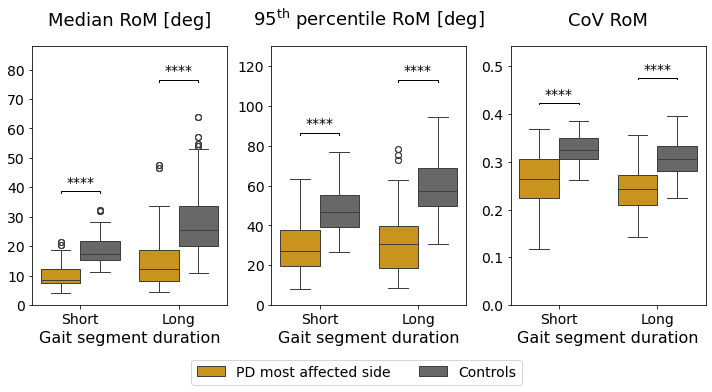

In [7]:
import statsmodels.formula.api as smf
import seaborn as sns
import matplotlib.pyplot as plt

filter_type = 'filtered'
segment_lengths = ['0_20', '20_inf']
verbose = False
save_plots = True

df_aggs_propark_ols = df_aggs_propark.loc[
    (df_aggs_propark['filter_type'] == filter_type)
    & (df_aggs_propark['segment_category'].isin(segment_lengths))
].copy()

group_renaming = {
    'pd': 'PD most affected side',
    'controls': 'Controls'
}

# Binary encodings
df_aggs_propark_ols['group_long'] = df_aggs_propark_ols['group'].map(group_renaming)

def compute_corrected(df, measure_col):
    df_regr = df.copy()
    df_regr = df_regr.rename(columns={measure_col: measure_col.replace("95p", "p95")})
    measure_col = measure_col.replace("95p", "p95")

    formula = f"{measure_col} ~ C(group) + gender"
    model = smf.ols(formula, data=df_regr).fit()

    return df_regr, model

# Compute corrected values for all measures and segments
corrected_dfs = []
ols_models = {}
for seg_len in segment_lengths:
    df_seg = df_aggs_propark_ols[df_aggs_propark_ols['segment_category'] == seg_len].copy()
    ols_models[seg_len] = {}

    for agg in aggregates:
        measure_col = f"{agg}_range_of_motion"
        df_regr, ols_models[seg_len][agg] = compute_corrected(df_seg, measure_col)

        corrected_dfs.append(df_regr)

df_corrected = pd.concat(corrected_dfs, ignore_index=True)

# Filter for plotting
df_plot = df_corrected.copy()

# Plot
fig, axes = plt.subplots(1, len(aggregates), figsize=(10,5), sharex=True)

for i, agg in enumerate(aggregates):
    sns.boxplot(
        x='segment_category', 
        hue='group_long', 
        y=f"{agg}_range_of_motion", 
        data=df_plot, 
        palette=[COLOR_GROUP_1, COLOR_GROUP_NEUTRAL], 
        hue_order=['PD most affected side', 'Controls'],
        ax=axes[i]
    )
    
    box_positions = {}
    n_segments = len(segment_lengths)
    hue_order = df_plot['group'].dropna().unique()
    n_groups = len(hue_order)
    
    # Compute pairwise statistics
    for seg_idx, seg_len in enumerate(segment_lengths):
        for group_idx, group in enumerate(hue_order):
            x = seg_idx - 0.4 + 0.8 * (group_idx + 0.5) / n_groups
            box_positions[(seg_len, group)] = x

    max_y_delta = 0.1 * df_plot[f"{agg}_range_of_motion"].max()
    
    # Compute pairwise statistics and plot significance
    for seg_idx, seg_len in enumerate(segment_lengths):
        sub_df = df_plot[df_plot['segment_category'] == seg_len]
        present_groups = sub_df['group'].dropna().unique()

        max_y = sub_df[f"{agg}_range_of_motion"].max()
        y_base = max_y + max_y_delta
    
        hypothesis = "C(group)[T.pd] = 0"
        print(f"Comparing {present_groups[0]} and {present_groups[1]}: {hypothesis}")

        t_res = ols_models[seg_len][agg].t_test(hypothesis)
        coef = t_res.effect[0]
        pval = t_res.pvalue.item()
        ci_low, ci_high = t_res.conf_int()[0]
        print(f"{seg_len}: {agg} - Δ={coef:.2f}, 95% CI=({np.round(ci_low, 2)}, {np.round(ci_high, 2)}), p={np.round(pval, 4)}")
                    
        x_min = box_positions[(seg_len, present_groups[0])]
        x_max = box_positions[(seg_len, present_groups[1])]

        if seg_idx == 1:
            y_sig = y_base + max_y_delta
        else:
            y_sig = y_base
        
        plot_significance(
            ax=axes[i], 
            x_min=x_min, 
            x_max=x_max, 
            pvalue=pval,
            y_min_significance=y_sig, 
            text_size=PLOT_TEXTSIZE
        )

    if 'cov' in agg:
        ylabel = f'{AGGREGATION_RENAMING[agg]} RoM'
    else:
        ylabel = f'{AGGREGATION_RENAMING[agg]} RoM [deg]'

    axes[i].set_title(ylabel, size=PLOT_TITLESIZE, pad=20)
    axes[i].set_ylabel('')
    axes[i].set_xlabel('Gait segment duration', size=PLOT_LABELSIZE)
    axes[i].set_xticks(range(len(segment_lengths)), ['Short', 'Long']) #[SEGMENT_DURATION_RENAMING[x] for x in segment_lengths])
    axes[i].tick_params(axis='both', labelsize=PLOT_TICKSIZE)

    axes[i].set_ylim(0, 1.1 * axes[i].get_ylim()[1])

    legend = axes[i].get_legend()
    if legend is not None:
        legend.remove()

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles, labels,
    loc='lower center',
    ncols=3,
    fontsize=PLOT_LEGEND_FONTSIZE,
    frameon=True,
    bbox_to_anchor=(0.5, -0.1) 
)

fig.tight_layout()
plt.show()

if save_plots:
    fig.savefig(PATH_FIGURES / 'sr_cs_group_diff_propark_rom_corrected.png', dpi=600, bbox_inches='tight')

median_range_of_motion x updrs_3_hypokinesia_off_ws N subjects: 42
Subjects: 12     10762
32     12075
44     17591
52     17881
76     23587
84     24732
96     26152
120    29580
128    29792
140    33560
160    35700
168    36794
176    37156
184    39825
220    42491
252    49279
256    50759
260    51308
264    51804
272    52493
280    53413
316    59660
324    60438
328    61199
340    62229
356    65257
360    65902
372    67892
380    69456
388    70609
400    71800
408    73100
416    73801
436    80118
444    84343
468    87939
480    89960
488    90579
496    92027
524    95963
532    97588
540    98331
Name: id, dtype: int64
median_range_of_motion x updrs_3_hypokinesia_off_non_ws N subjects: 42
Subjects: 12     10762
32     12075
44     17591
52     17881
76     23587
84     24732
96     26152
120    29580
128    29792
140    33560
160    35700
168    36794
176    37156
184    39825
220    42491
252    49279
256    50759
260    51308
264    51804
272    52493
280    53413


C:\Users\z665206\AppData\Local\Temp\ipykernel_19000\973811319.py:144: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


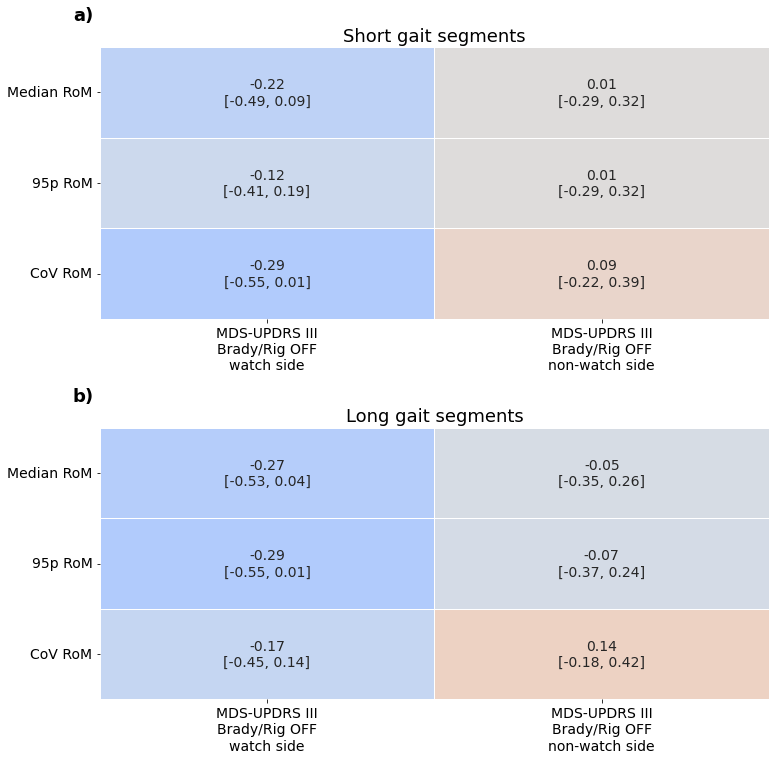

In [10]:
# Correlations
from matplotlib import gridspec

plot_vals = "ci"
med_status = "no_med"

clinical_scores = {
    'updrs_3_hypokinesia_off_ws': 'MDS-UPDRS III\nBrady/Rig OFF\nwatch side',
    'updrs_3_hypokinesia_off_non_ws': 'MDS-UPDRS III\nBrady/Rig OFF\nnon-watch side',
    # 'updrs_2_bradykinesia_rigidity': 'MDS-UPDRS II\nBrady/Rig',
    # 'pdq39_brady_rig': 'PDQ-39\nBrady/Rig',
}

df_cs_plot = df_aggs_propark_ols.loc[df_aggs_propark_ols['group'] == 'pd'].copy()

nrows_total = 2
ncols = 1
width = 12

fig = plt.figure(figsize=(width, 12))

gs = gridspec.GridSpec(
    nrows_total,
    ncols,
    hspace=0.4,
    wspace=0.02
)

axes = []
for i in range(nrows_total):
    row_axes = [fig.add_subplot(gs[i, j]) for j in range(ncols)]
    axes.append(row_axes)

for i, segment_length in enumerate(segment_lengths):
    ax = axes[i][0]
    
    heatmap_data = {}
    annot_data = {}

    df_filtered = df_cs_plot.loc[
        (df_cs_plot['segment_category'] == segment_length)
    ]

    if df_filtered.empty:
        continue

    for measure in measures:
        row_label = f'{measure.replace("_", " ").capitalize()}'
        x = df_filtered[measure]
        if x.isnull().all():
            continue

        heatmap_data[row_label] = {}
        annot_data[row_label] = {}

        for clinical_score, clinical_label in clinical_scores.items():
            y = df_filtered[clinical_score]
            if y.isnull().all():
                continue

            valid_idx = (~x.isnull()) & (~y.isnull())
            corr, p_val = spearmanr(x[valid_idx], y[valid_idx])
            samples = df_filtered.loc[valid_idx].shape[0]

            if plot_vals == 'pvals':
                if p_val < 0.001:
                    lower_label = '(p < 0.001)'
                elif p_val < 0.01:
                    lower_label = '(p < 0.01)'
                elif p_val < 0.05:
                    lower_label = '(p < 0.05)'
                else:
                    lower_label = f'(p = {np.round(p_val, 2)})'
            elif plot_vals == 'ci':
                lower, upper = calculate_ci(x[valid_idx], corr)
                lower_label = f'[{np.round(lower, 2)}, {np.round(upper, 2)}]'

            heatmap_data[row_label][clinical_label] = corr
            annot_data[row_label][clinical_label] = f"{corr:.2f}\n{lower_label}"

            print(f"{measure} x {clinical_score} N subjects: {len(valid_idx)}")
            print(f"Subjects: {df_filtered.loc[valid_idx, 'id']}")

    corr_df = pd.DataFrame.from_dict(heatmap_data, orient='index')
    annot_df = pd.DataFrame.from_dict(annot_data, orient='index')

    row_order = list(corr_df.index)
    if med_status == 'med':
        corr_df.loc['Medicated', :] = np.nan
        annot_df.loc['Medicated', :] = ""

    if med_status == 'no_med':
        corr_df.loc['Unmedicated', :] = np.nan
        annot_df.loc['Unmedicated', :] = ""
        
    corr_df = corr_df.loc[row_order]
    annot_df = annot_df.loc[row_order]

    corr_df.index = [x.replace('Medicated ', '').replace('Unmedicated ', '').replace('MAS', 'Most affected side').replace('LAS', 'Least affected side').replace('range of motion', 'RoM').replace('Median cov', 'CoV') for x in corr_df.index]
    annot_df.index = [x.replace('Medicated ', '').replace('Unmedicated ', '').replace('MAS', 'Most affected side').replace('LAS', 'Least affected side').replace('range of motion', 'RoM').replace('Median cov', 'CoV') for x in annot_df.index]

    # Plot
    sns.heatmap(
        corr_df,
        annot=annot_df,
        fmt="",
        cmap="coolwarm",
        center=0,
        linewidths=0.5,
        cbar=False,
        vmin=-1, vmax=1,
        annot_kws={"size": PLOT_TEXTSIZE},
        ax=ax
    )

    ax.set_ylabel('')

    ax.tick_params(axis='both', which='major', labelsize=PLOT_TICKSIZE)
    plt.setp(ax.get_xticklabels(), rotation=0, fontsize=PLOT_TICKSIZE)
    plt.setp(ax.get_yticklabels(), rotation=0, fontsize=PLOT_TICKSIZE)
    
    yticks = ax.get_yticklabels()
    for tick in yticks:
        if tick.get_text() in ['Medicated', 'Unmedicated']:
            tick.set_fontweight('bold')
            tick.set_fontsize(PLOT_TICKSIZE)

    if i == 0:
        subplot_label = 'a)'
    elif i == 1:
        subplot_label = 'b)'
    else:
        continue

    ax.text(
        -0.04, 1.15, subplot_label, fontweight='bold',
        ha='left', va='top', fontsize=PLOT_TITLESIZE,
        transform=ax.transAxes
    )

axes[0][0].set_title("Short gait segments", fontsize=PLOT_TITLESIZE)
axes[1][0].set_title("Long gait segments", fontsize=PLOT_TITLESIZE)

plt.tight_layout()
# plt.subplots_adjust(top=0.92)
plt.show()

fig.savefig(PATH_FIGURES / f'{med_status}_propark.png', dpi=300)

In [125]:
df_corr

,id,filter_type,segment_category,duration_s,median_range_of_motion,95p_range_of_motion,median_cov_range_of_motion,mean_cov_range_of_motion,median_peak_velocity,95p_peak_velocity,median_cov_peak_velocity,mean_cov_peak_velocity,visit,age,gender,group,watch_side,early_quit_date,early_quit_time,MedicationYN,ledd,ledd_daily_incl_nondaily,file_link,updrs_2_12,updrs_3_10,walking_aid_mult_choice,walking_aid_other,updrs_2_10,updrs_3_3b,updrs_3_3c,updrs_3_3d,updrs_3_3e,updrs_3_4a,updrs_3_4b,updrs_3_5a,updrs_3_5b,updrs_3_6a,updrs_3_6b,updrs_3_7a,updrs_3_7b,updrs_3_8a,updrs_3_8b,updrs_3_15a,updrs_3_15b,updrs_3_16a,updrs_3_16b,updrs_3_17a,updrs_3_17b,updrs_3_17c,updrs_3_17d,hoehn_yahr,dominant_side,updrs_3_hypokinesia_off_ws,updrs_3_hypokinesia_off_non_ws,affected_side,group_long


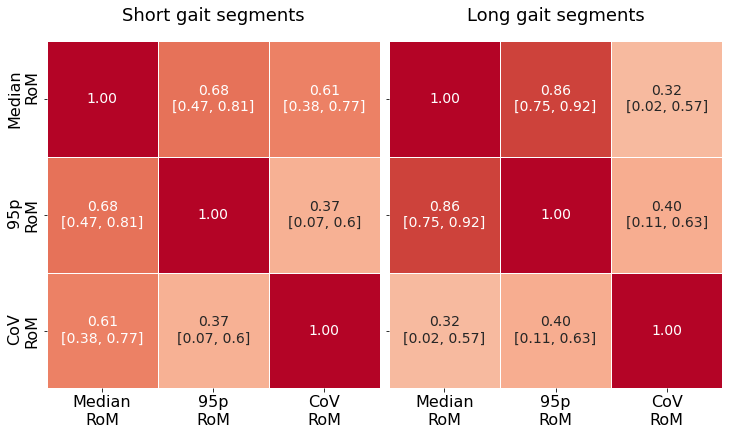

In [126]:
import seaborn as sns
from scipy.stats import spearmanr

plot_vals = 'ci'  # 'ci' or 'pvals'

fig, ax = plt.subplots(ncols=2, figsize=(12, 6), sharey=True)

df_corr = df_aggs_propark_ols.loc[df_aggs_propark_ols['group'] == 'pd']

for j, segment_length in enumerate(segment_lengths):
    df_segment = df_corr.loc[df_corr['segment_category'] == segment_length]

    if df_segment.empty:
        print(f"No data available for segment length: {segment_length}")
        continue

    median_rom = df_segment['median_range_of_motion'].values
    p_rom = df_segment['95p_range_of_motion'].values
    cv_rom = df_segment['median_cov_range_of_motion'].values

    corr_input_df = pd.DataFrame({
        'Median\nRoM': median_rom,
        '95p\nRoM': p_rom,
        'CoV\nRoM': cv_rom,
    })

    corr_df = corr_input_df.corr(method='spearman')
    annot_df = corr_df.copy().astype(str)

    for row in corr_df.columns:
        for col in corr_df.columns:
            if row == col:
                annot_df.loc[row, col] = "1.00"
                continue

            x = corr_input_df[row]
            y = corr_input_df[col]
            valid_idx = (~pd.isnull(x)) & (~pd.isnull(y))
            corr, p_val = spearmanr(x[valid_idx], y[valid_idx])

            if plot_vals == 'pvals':
                if p_val < 0.001:
                    lower_label = "(p < 0.001)"
                elif p_val < 0.01:
                    lower_label = "(p < 0.01)"
                elif p_val < 0.05:
                    lower_label = "(p < 0.05)"
                else:
                    lower_label = f"(p = {np.round(p_val, 2)})"
            elif plot_vals == 'ci':
                lower, upper = calculate_ci(x[valid_idx], corr)  # your helper
                lower_label = f"[{np.round(lower, 2)}, {np.round(upper, 2)}]"

            annot_df.loc[row, col] = f"{corr:.2f}\n{lower_label}"

    sns.heatmap(
        corr_df,
        annot=annot_df,
        fmt="",
        cmap="coolwarm",
        center=0,
        linewidths=0.5,
        cbar=False,
        vmin=-1, vmax=1,
        annot_kws={"size": PLOT_TEXTSIZE},
        ax=ax[j]
    )

    ax[j].tick_params(axis='both', which='major', labelsize=PLOT_LABELSIZE)

ax[0].set_title('Short gait segments', fontsize=PLOT_TITLESIZE, pad=20)
ax[1].set_title('Long gait segments', fontsize=PLOT_TITLESIZE, pad=20)

plt.tight_layout()
plt.subplots_adjust(top=0.92, right=0.84)
plt.show()

if save_plots:
    fig.savefig(PATH_FIGURES / 'sr_cs_corr_measures_propark.png', dpi=600, bbox_inches='tight')
    fig.savefig(PATH_FIGURES / 'vectors' /'sr_cs_corr_measures_propark.pdf', dpi=600, bbox_inches='tight')
